In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from empiricaldist import Pmf, Cdf
from scipy.stats import chi2_contingency


In [2]:
########################## CARGA DESDE ARCHIVO LOCAL ##########################
# Cargar el archivo local
df = pd.read_csv("dataset_penguins.csv")
# Ver las primeras filas
display(df)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [3]:
# custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
# sns.set_palette(custom_colors)

custom_palette_species = {
    'Adelie': '#1f77b4',  # azul
    'Chinstrap': '#ff7f0e',  # naranja
    'Gentoo': '#2ca02c'  # verde
}

# 📊 1.3 – Correlaciones: fundamentos para análisis exploratorio

## 🧠 ¿Qué es la correlación?
La correlación es una medida estadística que indica el **grado de relación o asociación entre dos variables**.
- Permite identificar si dos variables:
  - Aumentan juntas
  - Disminuyen juntas
  - O no presentan relación aparente
⚠️ Importante:
> **Correlación no implica causalidad**  
Que dos variables estén relacionadas no significa que una cause la otra.
(pero dos hechos aparentemente correlacionados si podrian tener una causa comun - variables ocultas)

## 🔗 Tipos de correlación
### 📈 Correlación positiva
Cuando una variable aumenta, la otra también tiende a aumentar.
Ejemplo:
- Mayor fertilización → mayor concentración de nutrientes
### 📉 Correlación negativa
Cuando una variable aumenta, la otra tiende a disminuir.
Ejemplo:
- Mayor edad del cultivo → menor concentración de ciertos nutrientes
### ⚪ Correlación nula
No existe una relación clara entre las variables.
cultivo vs una variable no relacionada

## 📐 Correlación lineal vs no lineal
### 📏 Correlación lineal
Existe una relación proporcional entre variables.
👉 Representación:
- Línea recta (positiva o negativa)
Es la que mide el **coeficiente de Pearson**.
### 🌊 Correlación no lineal
Existe relación, pero no sigue una línea recta.
Ejemplo:
- Relación curva (parabólica, exponencial, etc.)
💡 Importante:
> Dos variables pueden tener **relación fuerte pero Pearson ≈ 0**
si la relación no es lineal.

## 📊 Coeficiente de correlación de Pearson (r)
Es la medida más utilizada para evaluar **correlación lineal**.
### 📌 Rango de valores
- r = 1 → correlación positiva perfecta  
- r = -1 → correlación negativa perfecta  
- r = 0 → sin correlación lineal  
----Interpretación general-----
| Valor de r | Interpretación |
|----------|----------------|
| 0.0 – 0.2 | Muy débil o nula |
| 0.2 – 0.4 | Débil |
| 0.4 – 0.6 | Moderada |
| 0.6 – 0.8 | Fuerte |
| 0.8 – 1.0 | Muy fuerte |
*(rangos son orientativos, no absolutos)*

- Pearson:
  - Solo detecta relaciones lineales
  - Puede fallar con relaciones complejas

## 🔍 Otras medidas de correlación
### 🧮 Spearman (ρ)
- Mide correlación **monótona**
- No requiere relación lineal
- Usa rangos en lugar de valores
👉 Útil cuando:
- Hay datos no normales
- Hay outliers
- Relaciones no lineales
### 🧮 Kendall (τ)
- Similar a Spearman
- Más robusto en datasets pequeños


In [ ]:
## Correlaciones entre variables numéricas ##
# .corr()
# Ej:
#df.corr() #ValueError: could not convert string to float: 'Adelie'...

processed_penguins_df = df.copy()

# quitar columnas categórica de island para evitar error al calcular correlación
processed_penguins_df = processed_penguins_df.drop(columns=['island'])

# Convertir columnas categóricas a numéricas
processed_penguins_df['species'] = processed_penguins_df['species'].astype('category').cat.codes
    # Adelie: 0, Chinstrap: 1, Gentoo: 2 (orden alfabético)

# Convertir columnas categóricas a numéricas (si es necesario)
processed_penguins_df['sex_ast'] = processed_penguins_df['sex'].astype('category').cat.codes
    # -1 puede interpretarse como valor real (para correlacion y analisis estadistico evitar usar -1)
processed_penguins_df['sex_map'] = processed_penguins_df['sex'].replace(['female', 'male'], [0, 1])
    # Male: 0, Female: 1   # genera NaN para valores faltantes (missing values)
#processed_penguins_df.head(1)
#0	0	39.1	18.7	181.0	3750.0	NaN	2007-1	NaN
processed_penguins_df = processed_penguins_df.drop(columns=['sex'])  # eliminar columna original de sex
processed_penguins_df = processed_penguins_df.drop(columns=['sex_ast'])  # eliminar columna original de sex
processed_penguins_df = processed_penguins_df.drop(columns=['year'])  # eliminar columna original de year // no es relevante para correlación

#processed_penguins_df.head(5)

print("Matriz de Correlación:")
processed_penguins_df.corr()

# - Calcula la matriz de correlación entre todas las columnas numéricas
# - Los valores van de -1 a 1:
#   - 1: correlación positiva perfecta (cuando una sube, la otra sube)
#   - -1: correlación negativa perfecta (cuando una sube, la otra baja)
#   - 0: sin correlación lineal
# - Solo funciona con columnas numéricas (las categóricas como `species` o `sex` se ignoran automáticamente)
# Si hay columnas con strings/objetos, lanza error

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_map
0,0,39.1,18.7,181.0,3750.0,1
1,0,39.5,17.4,186.0,3800.0,0
2,0,40.3,18.0,195.0,3250.0,0
3,0,NaN,NaN,NaN,NaN,NaN
4,0,36.7,19.3,193.0,3450.0,0


## 📉 Visualización de correlaciones
### 🔥 Heatmap (mapa de calor)
- Muestra la matriz de correlación
- Permite ver relaciones entre múltiples variables
- Colores indican intensidad y dirección


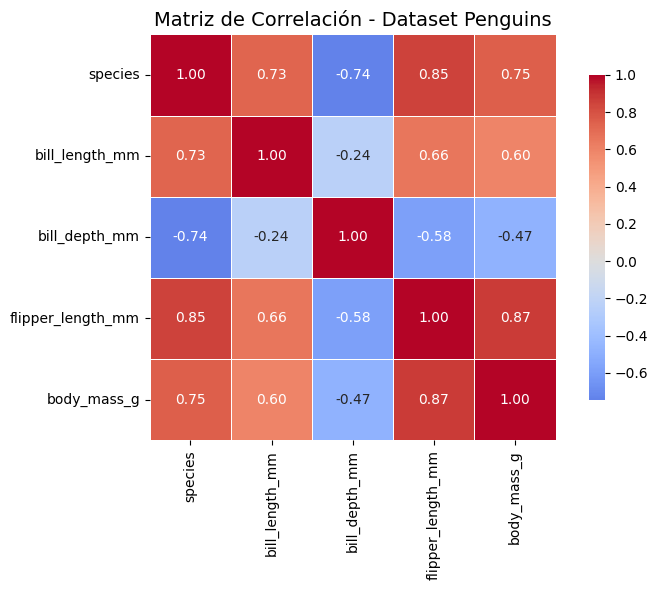

In [22]:
# Seleccionar solo columnas numéricas
#columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
df_numerico = processed_penguins_df.select_dtypes(include=[np.number])

# Calcular matriz de correlación
correlacion = df_numerico.corr()

# Configurar tamaño de la figura
plt.figure(figsize=(8, 6))

# Crear heatmap
sns.heatmap(correlacion, 
            # data=df.corr(),
            # data = df_numerico,
            annot=True,           # Mostrar valores numéricos
            fmt='.2f',            # Formato con 2 decimales
            #cmap=sns.diverging_palette (20, 230, as_cmap=True),
            cmap='coolwarm',      # Mapa de colores (rojo=positivo, azul=negativo)
            center=0,             # Centro en 0
            # vmin=-1,             # Valor mínimo para el mapa de colores
            # vmax=1,              # Valor máximo para el mapa de colores
            square=True,          # Celdas cuadradas
            linewidths=0.5,       # Líneas entre celdas
            cbar_kws={'shrink': 0.8})  # Ajustar tamaño de barra de color

plt.title('Matriz de Correlación - Dataset Penguins', fontsize=14)
plt.tight_layout()
plt.show()

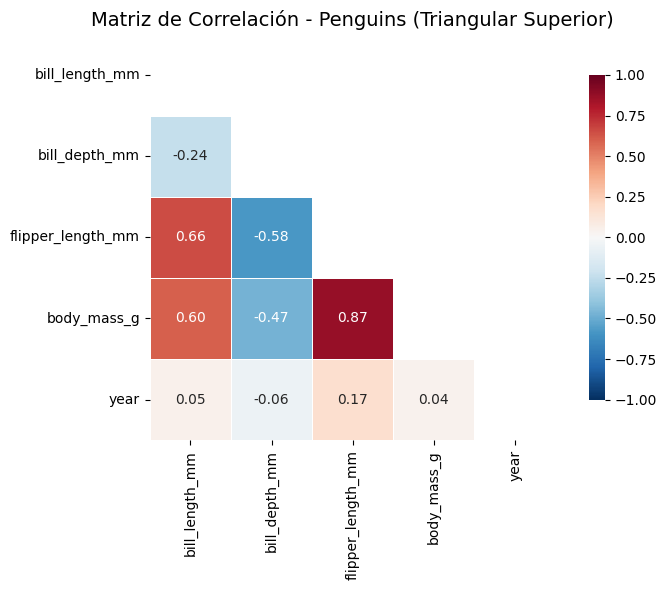


🔍 Correlaciones más fuertes:
flipper_length_mm  body_mass_g          0.871202
body_mass_g        flipper_length_mm    0.871202
flipper_length_mm  bill_length_mm       0.656181
bill_length_mm     flipper_length_mm    0.656181
body_mass_g        bill_length_mm       0.595110
bill_length_mm     body_mass_g          0.595110
year               flipper_length_mm    0.169675
flipper_length_mm  year                 0.169675
bill_length_mm     year                 0.054545
year               bill_length_mm       0.054545
dtype: float64


In [ ]:
## Heatmap con máscara para mostrar solo la mitad de la matriz (opcional) ##

# Seleccionar columnas numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
df_numerico = df[columnas_numericas]

# Calcular correlación
correlacion = df_numerico.corr()

# Crear máscara para la parte superior (opcional, evita redundancia)
mask = np.triu(np.ones_like(correlacion, dtype=bool))

# Configurar figura
plt.figure(figsize=(8, 6))

# Heatmap con máscara
sns.heatmap(correlacion, 
            mask=mask,            # Ocultar parte superior
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',        # Otro esquema de colores
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1)      # Fijar rango de correlación

plt.title('Matriz de Correlación - Penguins (Triangular Superior)', fontsize=14)
plt.tight_layout()
plt.show()

# Mostrar las correlaciones más altas (opcional)
print("\n🔍 Correlaciones más fuertes:")
corr_pares = correlacion.unstack().sort_values(ascending=False)
corr_pares = corr_pares[corr_pares < 1]  # Excluir correlación consigo misma
print(corr_pares.head(10))

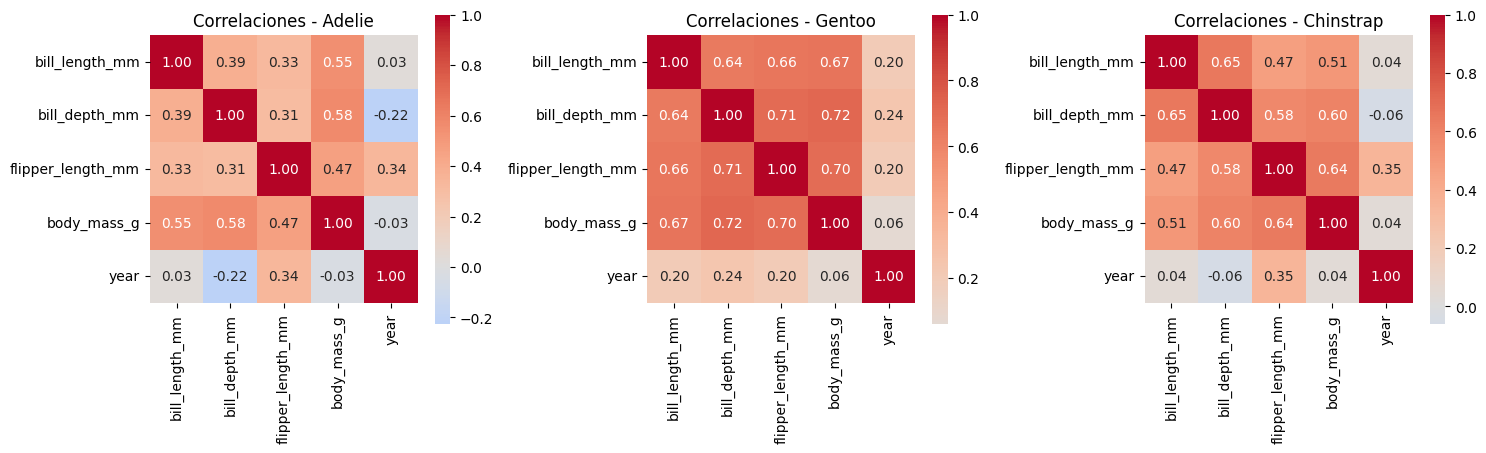

In [9]:
# Seleccionar columnas numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Crear subplots por especie
especies = df['species'].unique()
fig, axes = plt.subplots(1, len(especies), figsize=(15, 5))

for i, especie in enumerate(especies):
    df_especie = df[df['species'] == especie]
    df_num = df_especie[columnas_numericas].dropna()
    correlacion = df_num.corr()
    
    sns.heatmap(correlacion, 
                annot=True, 
                fmt='.2f',
                cmap='coolwarm',
                center=0,
                square=True,
                ax=axes[i],
                cbar_kws={'shrink': 0.8})
    axes[i].set_title(f'Correlaciones - {especie}', fontsize=12)

plt.tight_layout()
plt.show()

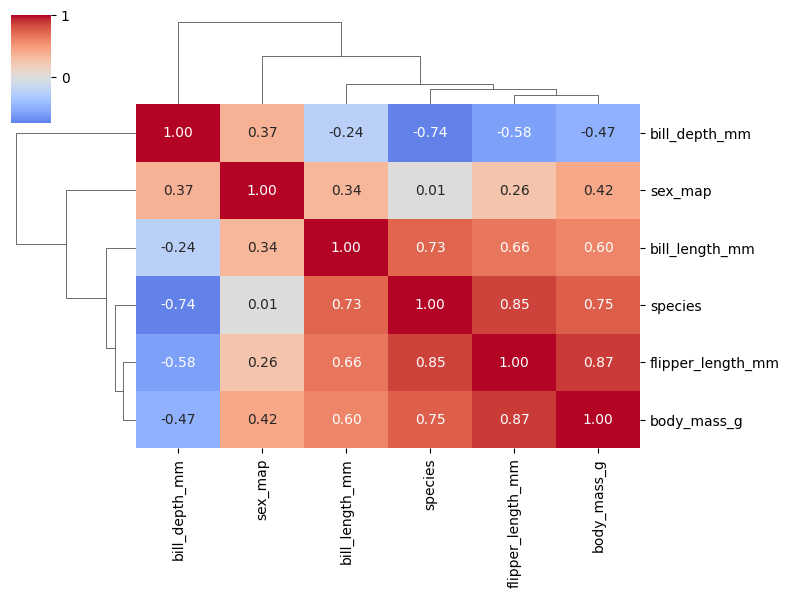

In [ ]:
sns.clustermap(processed_penguins_df.corr(), 
               annot=True,      # Muestra los valores
               fmt='.2f',       # Formato 2 decimales
               cmap='coolwarm', # Mapa de colores
               center=0,        # Centro en 0
               figsize=(8, 6)) # Tamaño

plt.show()


# **¿Qué hace clustermap?**
# - Es un heatmap que además **agrupa (clusteriza)** filas y columnas
# - Agrupa las variables que tienen correlaciones similares
# - Útil para ver patrones de agrupación natural entre variables

# flipper_length_mm y body_mass_g suelen estar fuertemente correlacionados, ya que ambos miden aspectos relacionados con el tamaño del pingüino.
# la especie (aunque hay 3) muestra correlaciones positivas con medidas corporales, ya que cada especie tiene un tamaño promedio diferente.
# Los pingüinos machos suelen ser más grandes, así que probablemente verás correlaciones positivas con `body_mass_g` y medidas corporales.
# bill_length_mm y bill_depth_mm tiene correlaciones más bajas, puede ser porque miden aspectos diferentes del pico.


## 📉 Visualización de correlaciones
### 📍 Scatter plot
- Permite ver la relación directa entre dos variables
- Ayuda a identificar:
  - Linealidad
  - Outliers
  - Patrones no lineales


**Scatter plot básico con matplotlib** (NO DICE MUCHO SOBRE LA RELACION ENTRE LAS VARIABLES, SOLO MUESTRA LOS PUNTOS)
plt.figure(figsize=(8, 6))
plt.scatter(df['bill_length_mm'], df['flipper_length_mm'], alpha=0.5)
plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Profundidad del pico (mm)')
plt.title('Relación entre longitud y profundidad del pico')
plt.grid(True, alpha=0.3)
plt.show()
  

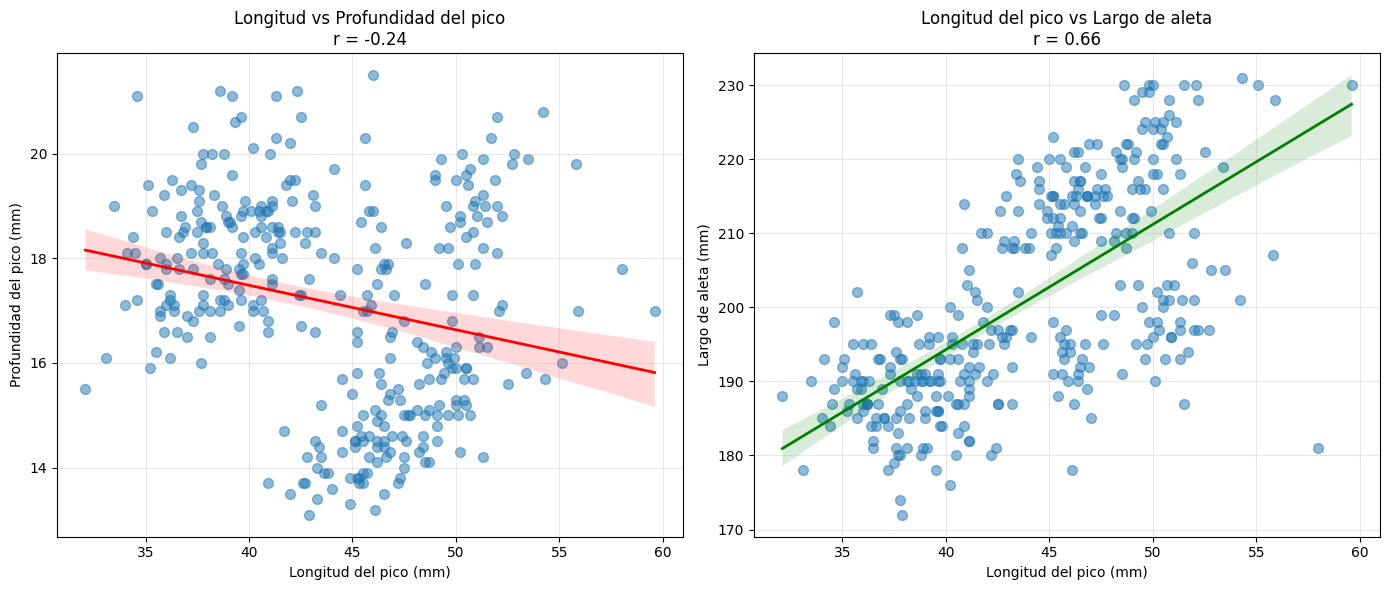

📊 Correlación entre longitud y profundidad: -0.24 (negativa)
📊 Correlación entre longitud y largo de aleta: 0.66 (positiva)


In [39]:
# Calcular correlaciones
corr1, p1 = pearsonr(df['bill_length_mm'].dropna(), df['bill_depth_mm'].dropna())
corr2, p2 = pearsonr(df['bill_length_mm'].dropna(), df['flipper_length_mm'].dropna())

# Crear figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Correlación negativa
sns.regplot(data=df, x='bill_length_mm', y='bill_depth_mm',
            scatter_kws={'alpha': 0.5, 's': 50},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=ax1)
ax1.set_title(f'Longitud vs Profundidad del pico\nr = {corr1:.2f}')
ax1.set_xlabel('Longitud del pico (mm)')
ax1.set_ylabel('Profundidad del pico (mm)')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Correlación positiva
sns.regplot(data=df, x='bill_length_mm', y='flipper_length_mm',
            scatter_kws={'alpha': 0.5, 's': 50},
            line_kws={'color': 'green', 'linewidth': 2},
            ax=ax2)
ax2.set_title(f'Longitud del pico vs Largo de aleta\nr = {corr2:.2f}')
ax2.set_xlabel('Longitud del pico (mm)')
ax2.set_ylabel('Largo de aleta (mm)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Correlación entre longitud y profundidad: {corr1:.2f} (negativa)")
print(f"📊 Correlación entre longitud y largo de aleta: {corr2:.2f} (positiva)")

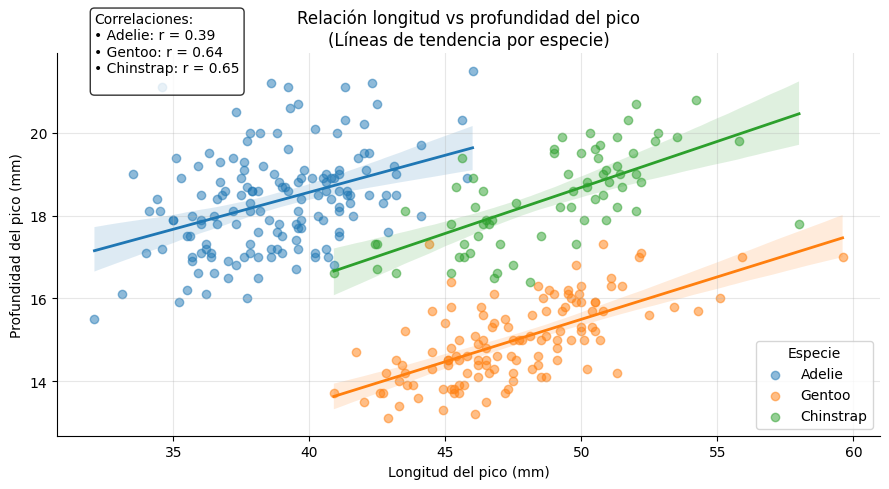

In [74]:
## 3. Scatter plot por especie (para ver patrones diferenciados)
#plt.figure(figsize=(8, 4))
sns.lmplot(  # Añadir línea de regresión para CADA especie
    data=df,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    legend=False, # quitar la leyenda por defecto
    #palette='deep',
    #palette=custom_palette_species, no funciona con lmplot, solo con regplot 
        # se podria para una lista de colores personalizada // custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    # Opciones de la línea de tendencia
    #ci=95,  # intervalo de confianza para la línea de tendencia
    #scatter=False,
    scatter_kws={'alpha': 0.5},
    line_kws={'linewidth': 2}, # 2 es un buen grosor para la línea de tendencia
    # Dimensiones del gráfico
    height=5,
    aspect=1.8
)

# Añadir texto con correlaciones en el gráfico
# Obtener coordenadas para el texto
x_min, x_max = df['bill_length_mm'].min(), df['bill_length_mm'].max()
y_min, y_max = df['bill_depth_mm'].min(), df['bill_depth_mm'].max()
# Posicionar texto en la esquina superior izquierda
text_x = x_min + (x_max - x_min) * 0.00
text_y = y_max - (y_max - y_min) * 0.05
# Crear texto con las correlaciones
texto = "Correlaciones:\n"
for especie, corr in corr_por_especie.items():
    texto += f"• {especie}: r = {corr:.2f}\n"
# Añadir texto al gráfico
plt.text(text_x, text_y, texto, 
         fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


plt.title('Relación longitud vs profundidad del pico\n(Líneas de tendencia por especie)')
plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Profundidad del pico (mm)')
plt.legend(title='Especie', loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
print("="*50)
print("📊 ANÁLISIS DE CORRELACIONES")

print(f"📈 Correlación GENERAL (todas las especies):")
print(f"   r = {corr_general:.3f}")
print(f"   Interpretación: Correlación {'negativa' if corr_general < 0 else 'positiva'} {abs(corr_general):.2f}")

print(f"📊 Correlaciones por ESPECIE:")
print("-"*40)
for especie, corr in correlaciones_por_especie.items():
    if not np.isnan(corr):
        direccion = "negativa" if corr < 0 else "positiva"
        intensidad = "fuerte" if abs(corr) > 0.7 else "moderada" if abs(corr) > 0.3 else "débil"
        print(f"   🐧 {especie}: r = {corr:.3f} ({direccion}, {intensidad})")
    else:
        print(f"   🐧 {especie}: No se pudo calcular (datos insuficientes)")
print("="*50)
print("💡 INTERPRETACIÓN:")
if corr_general < 0:
    print("   • En general, a MAYOR longitud del pico, MENOR profundidad")
else:
    print("   • En general, a MAYOR longitud del pico, MAYOR profundidad")
print("   • Observa cómo la relación puede variar según la especie")

print("🧩 Paradoja de Simpson")

print("""INTERPRETACIÓN:
⚠️ ¿CÓMO ES POSIBLE?
   Las distintas especies ocupan regiones diferenciadas en el gráfico:
   • Gentoo: picos MÁS LARGOS pero MENOS PROFUNDOS (zona inferior derecha)
   • Adelie y Chinstrap: picos MÁS CORTOS pero MÁS PROFUNDOS (zona superior izquierda)
   Al combinar todas las especies en un solo análisis, las diferencias ENTRE especies
   dominan sobre la relación interna de cada grupo, generando una inversión en la tendencia global.

💡 CONCLUSIÓN:
La correlación global NEGATIVA es un ARTEFACTO ESTADÍSTICO (no refleja una relación real),
   • dada la agregación de datos está sesgada por la mezcla de grupos (en este caso las especies). (A nivel agregado, la relación parece negativa)
 • Sin embargo, al segmentar por especie, la relación es POSITIVA en cada y en todos los casos.
 • Por tanto es más adecuado interpretar las relaciones dentro de cada especie.
""")

📊 ANÁLISIS DE CORRELACIONES
📈 Correlación GENERAL (todas las especies):
   r = -0.235
   Interpretación: Correlación negativa 0.24
📊 Correlaciones por ESPECIE:
----------------------------------------
   🐧 Adelie: r = 0.391 (positiva, moderada)
   🐧 Gentoo: r = 0.643 (positiva, moderada)
   🐧 Chinstrap: r = 0.654 (positiva, moderada)
💡 INTERPRETACIÓN:
   • En general, a MAYOR longitud del pico, MENOR profundidad
   • Observa cómo la relación puede variar según la especie
🧩 Paradoja de Simpson
INTERPRETACIÓN:
⚠️ ¿CÓMO ES POSIBLE?
   Las distintas especies ocupan regiones diferenciadas en el gráfico:
   • Gentoo: picos MÁS LARGOS pero MENOS PROFUNDOS (zona inferior derecha)
   • Adelie y Chinstrap: picos MÁS CORTOS pero MÁS PROFUNDOS (zona superior izquierda)
   Al combinar todas las especies en un solo análisis, las diferencias ENTRE especies
   dominan sobre la relación interna de cada grupo, generando una inversión en la tendencia global.

💡 CONCLUSIÓN:
La correlación global NEGATIVA 

## ⚠️ Consideraciones importantes
- La correlación:
  - No detecta causalidad
  - Puede verse afectada por outliers
  - Solo mide relaciones entre dos variables a la vez
  
> La correlación es una herramienta exploratoria que ayuda a encontrar patrones, pero siempre debe interpretarse con criterio y contexto del dominio.

## 📘 Introducción Teórica: Regresión Lineal y Análisis de Tendencias

### 📈 ¿Qué es una línea de tendencia central?
La **línea de tendencia central** (también llamada **recta de regresión lineal**) es un modelo matemático que resume la relación entre dos variables. Su ecuación general es:
```
Y = m · X + b
```
Donde:
- **m** = **pendiente** → cuánto cambia Y cuando X aumenta en 1 unidad
- **b** = **intercepto** → valor de Y cuando X = 0 (valor de referencia)
**¿Por qué "central"?** Porque la recta pasa por el "centro" de la nube de puntos, minimizando la distancia entre los puntos observados y la línea.

### 📐 ¿Qué nos dice la pendiente (m)?
La pendiente es el corazón de la interpretación:

| Tipo de pendiente | Significado | Interpretación biológica (ejemplo) |
|-------------------|-------------|-----------------------------------|
| **m > 0 (positiva)** | Relación **directa** | A mayor largo de aleta, mayor masa corporal |
| **m < 0 (negativa)** | Relación **inversa** | A mayor largo de aleta, menor masa corporal |
| **m ≈ 0** | No hay relación lineal | Las variables no están asociadas linealmente |

**Magnitud de la pendiente:**
- Una pendiente **empinada** (valor grande) → cambios bruscos en Y ante pequeños cambios en X
- Una pendiente **suave** (valor pequeño) → cambios graduales en Y

### 📊 ¿Qué nos dice el coeficiente de correlación (r)?

El coeficiente de Pearson **r** complementa la pendiente:

| r | Interpretación |
|---|----------------|
| **+1** | Correlación positiva perfecta |
| **0** | Sin correlación lineal |
| **-1** | Correlación negativa perfecta |

**Fuerza de la relación:**
- `|r| > 0.7` → correlación fuerte
- `0.3 < |r| < 0.7` → correlación moderada
- `|r| < 0.3` → correlación débil



### 🧮 ¿Qué es R² (coeficiente de determinación)?
R² mide **qué tan bien la recta explica los datos**:

```
R² = (correlación)²
```

**Interpretación:**
- R² = 0.70 → el 70% de la variabilidad en Y es explicada por X
- R² cercano a 1 → excelente ajuste
- R² cercano a 0 → mala predicción

**Fórmula en contexto:**
```
R² = 1 - (varianza de los residuos) / (varianza total)
```

### 🧠 ¿Por qué es importante este análisis?

1. **Entender relaciones biológicas**: ¿El tamaño corporal está asociado al tamaño de las aletas?
2. **Predecir valores**: Si conozco el largo de la aleta, ¿puedo estimar la masa corporal?
3. **Comparar especies**: ¿La relación es igual en Adelie, Gentoo y Chinstrap?
4. **Base para modelos más complejos**: La regresión lineal es el punto de partida para análisis estadísticos avanzados

---

##### 🎯 Objetivo del análisis - para entender de forma practica la correlación entre variables numéricas

En este caso:
Se estudiara la **relación entre dos variables numéricas** en los pingüinos Adelie:
- **Variable independiente (X):** `flipper_length_mm` (largo de la aleta)
- **Variable dependiente (Y):** `body_mass_g` (masa corporal)

Se busca responder:
- ¿Existe relación entre ambas variables?
- ¿La relación es positiva o negativa?
- ¿Qué tan fuerte es la relación?
- ¿Cuánto cambia la masa corporal por cada mm de aleta?
- ¿Qué tan bien la longitud de la aleta explica la masa corporal?
- ¿Tiene sentido desde un punto de vista biológico?


In [102]:
# Filtrar solo la especie Adelie
df_adelie = df[df['species'] == 'Adelie'].dropna(subset=['flipper_length_mm', 'body_mass_g'])

print("="*60)
print("📊 ANÁLISIS DE RELACIÓN: Adelie")
print("="*60)
print(f"📌 Muestra analizada: {len(df_adelie)} pingüinos Adelie")
print(f"📌 Variables: flipper_length_mm (largo de aleta) vs body_mass_g (masa corporal)")
print("="*60)


📊 ANÁLISIS DE RELACIÓN: Adelie
📌 Muestra analizada: 151 pingüinos Adelie
📌 Variables: flipper_length_mm (largo de aleta) vs body_mass_g (masa corporal)


In [104]:

# Calcular correlación
corr, p_valor = pearsonr(df_adelie['flipper_length_mm'], df_adelie['body_mass_g'])

print(f"\n📈 COEFICIENTE DE CORRELACIÓN (Pearson):")
print(f"   r = {corr:.3f}")
print(f"   p-valor = {p_valor:.3e}")
print(f"\n   Interpretación: Correlación {'positiva' if corr > 0 else 'negativa'} ")
print(f"   {'fuerte al ser > 0.7' if abs(corr) > 0.7 else 'moderada al ser > 0.3' if abs(corr) > 0.3 else 'débil al ser <= 0.3'}")



📈 COEFICIENTE DE CORRELACIÓN (Pearson):
   r = 0.468
   p-valor = 1.343e-09

   Interpretación: Correlación positiva 
   moderada al ser > 0.3


In [ ]:

# Modelo de regresión lineal
X = df_adelie['flipper_length_mm'].values.reshape(-1, 1)
y = df_adelie['body_mass_g'].values

modelo = LinearRegression() 
# LinearRegression() es un modelo de regresión lineal que encuentra la mejor línea recta que se ajusta a los datos, minimizando la suma de los errores al cuadrado entre las predicciones y los valores reales.
modelo.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
# Extraer coeficientes
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"\n📐 ECUACIÓN DE LA RECTA DE TENDENCIA:")
print(f"   body_mass_g = {pendiente:.2f} × flipper_length_mm + {intercepto:.2f}")
print(f"\n   🔹 Pendiente = {pendiente:.2f}")
print(f"   🔹 Intercepto = {intercepto:.2f}")



📐 ECUACIÓN DE LA RECTA DE TENDENCIA:
   body_mass_g = 32.83 × flipper_length_mm + -2535.84

   🔹 Pendiente = 32.83
   🔹 Intercepto = -2535.84


In [107]:

# Calcular R²
r2 = modelo.score(X, y)
print(f"\n🎯 COEFICIENTE DE DETERMINACIÓN (R²):")
print(f"   R² = {r2:.3f}")
print(f"   Interpretación: {r2*100:.1f}% de la variabilidad en masa corporal")
print(f"   es explicada por la longitud de la aleta")


🎯 COEFICIENTE DE DETERMINACIÓN (R²):
   R² = 0.219
   Interpretación: 21.9% de la variabilidad en masa corporal
   es explicada por la longitud de la aleta


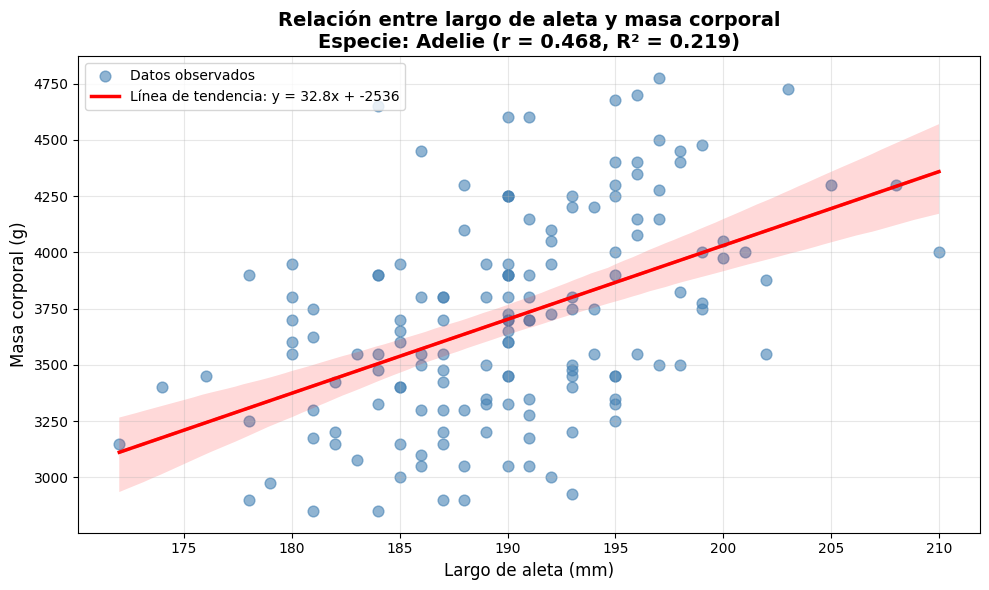

In [108]:
# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(df_adelie['flipper_length_mm'], df_adelie['body_mass_g'], 
           alpha=0.6, s=60, color='steelblue', label='Datos observados')

# Línea de regresión (tendencia central)
x_range = np.linspace(df_adelie['flipper_length_mm'].min(), 
                      df_adelie['flipper_length_mm'].max(), 100)
y_pred = pendiente * x_range + intercepto
ax.plot(x_range, y_pred, color='red', linewidth=2.5, 
        label=f'Línea de tendencia: y = {pendiente:.1f}x + {intercepto:.0f}')

# Intervalo de confianza (opcional - usando seaborn)
sns.regplot(data=df_adelie, x='flipper_length_mm', y='body_mass_g',
            scatter=False, ci=95, color='red', ax=ax, 
            line_kws={'linestyle': '--', 'alpha': 0.5})

ax.set_xlabel('Largo de aleta (mm)', fontsize=12)
ax.set_ylabel('Masa corporal (g)', fontsize=12)
ax.set_title(f'Relación entre largo de aleta y masa corporal\nEspecie: Adelie (r = {corr:.3f}, R² = {r2:.3f})', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### RECOPILANDO OUTPUTS CLAVE DEL ANÁLISIS:

* r → dirección + fuerza
* pendiente → cuánto cambia Y
* R² → qué tanto explica X
* p-valor → si es real o azar

### 📊 ANÁLISIS DE RELACIÓN: Pingüinos Adelie

📌 Muestra analizada: 151 individuos.  
📌 Variables: flipper_length_mm (aleta) vs body_mass_g (masa).  
/////  
📈 COEFICIENTE DE CORRELACIÓN (Pearson):  
   👉 r = 0.468  
   p-valor = 1.343e-09  o 0.0000000001343
   **Interpretación:**  
   • Existe una correlación positiva moderada.  
   • A mayor longitud de aleta, mayor masa corporal.  
   • El p-valor indica que la relación es estadísticamente significativa.  
   • La relación **sí existe** (no es por azar) pero no necesariamente fuerte, pero 'significativa'.

   ¿Qué tan probable es observar estos datos si en realidad NO hay relación? (ver p-valor)
   La probabilidad de que esta relación ocurra por azar es prácticamente cero.

| p-valor    | Interpretación                  |
| ---------- | ------------------------------- |
| p < 0.05   | significativo                   |
| p < 0.01   | muy significativo               |
| p << 0.001 | 🔥 extremadamente significativo |

Nota: un valor p-valor de por ejemplo 0.05 es un umbral común para determinar significancia estadística, pero no mide la fuerza de la relación, solo su probabilidad de ser debida al azar.

✅ p-valor → MUY significativo
⚠️ r = 0.468 → relación moderada
⚠️ R² = 0.219 → explica poco

/////  
📐 ECUACIÓN DE LA RECTA DE TENDENCIA:  
   body_mass_g = 32.83 × flipper_length_mm - 2535.84  
   👉 Pendiente = 32.83
   Esto es lo más interpretable:

   > Por cada 1 mm de aleta → +32.83 g de masa

   ✔ Esto es tangible ya que:
      → Por cada 1 mm adicional de longitud de aleta,
        la masa corporal aumenta en promedio 32.83 g.  
   🔹 Intercepto = -2535.84  
      → Valor teórico cuando la aleta es 0 mm (sin interpretación biológica real).  
/////  
🎯 COEFICIENTE DE DETERMINACIÓN (R²):  
   👉 R² = 0.219  
   **Interpretación:**  
   • Solo el 21.9% de la variabilidad en la masa corporal  
     es explicada por la longitud de la aleta.  
   • El restante 78.1% depende de otros factores  
     (edad, alimentación, sexo, genética, etc.).  
/////   

#### RESUMEN DE HALLAZGOS:  
• CORRELACIÓN (r = 0.468): Relación positiva moderada entre   
   longitud de aleta y masa corporal.   
• SIGNIFICANCIA (p < 0.001): La relación es extremadamente   
   significativa. La probabilidad de que ocurra por azar es   
   prácticamente nula (1 en 10 mil millones).  
• PENDIENTE (32.83): Por cada 1 mm adicional de aleta, la masa   
   corporal aumenta en promedio 32.83 gramos. En términos prácticos:  
      → 10 mm adicionales → +328 g de masa  
      → 20 mm adicionales → +657 g de masa  
• PODER EXPLICATIVO (R² = 0.219): Solo el 22% de la variabilidad   
   en masa corporal es explicada por la longitud de la aleta.  

   • Sexo (machos son más grandes que hembras)
   • Estado nutricional y alimentación
   • Época del año (pre/post muda, reproducción)
   • Edad del individuo
   • Variabilidad genética intraespecie


> Existe una relación positiva significativa entre la longitud de la aleta y la masa corporal, pero su capacidad explicativa es limitada, lo que sugiere la influencia de múltiples factores adicionales.

Sugerencia:
Se podria agregar **más variables (regresión múltiple)**
Se podria analizar otras especies para comparar relaciones
Se podria analizar la relación no lineal entre variables (regresión polinomial, etc.)
Se podria analizar la relación entre variables categóricas (ANOVA, etc.)
Se puede cambiar el modelo a uno no lineal si se sospecha que la relación no es lineal (regresión polinomial, etc.)


💡 CONCLUSIÓN:

   • Existe una relación positiva y significativa entre el tamaño de la aleta
     y la masa corporal en pingüinos Adelie.  
   • Sin embargo, la relación no es fuerte, por lo que la longitud de la aleta
     por sí sola no es un buen predictor de la masa corporal.  
   • Desde un punto de vista biológico, el resultado es coherente:
     individuos más grandes tienden a tener aletas más largas.  

💡 IMPORTANTE:

- Intercambiar ejes cambia el significado y el valor numérico de la pendiente, aunque la correlación (r) y R² se mantienen.
por ejemplo:
Pendiente 	32.83 g/mm	0.0067 mm/g(pendiente inversa)
- cambia la pregunta :
¿Cómo cambia la masa cuando aumenta la aleta?

## 📊 RECOPILATORIO Tipos de correlaciones



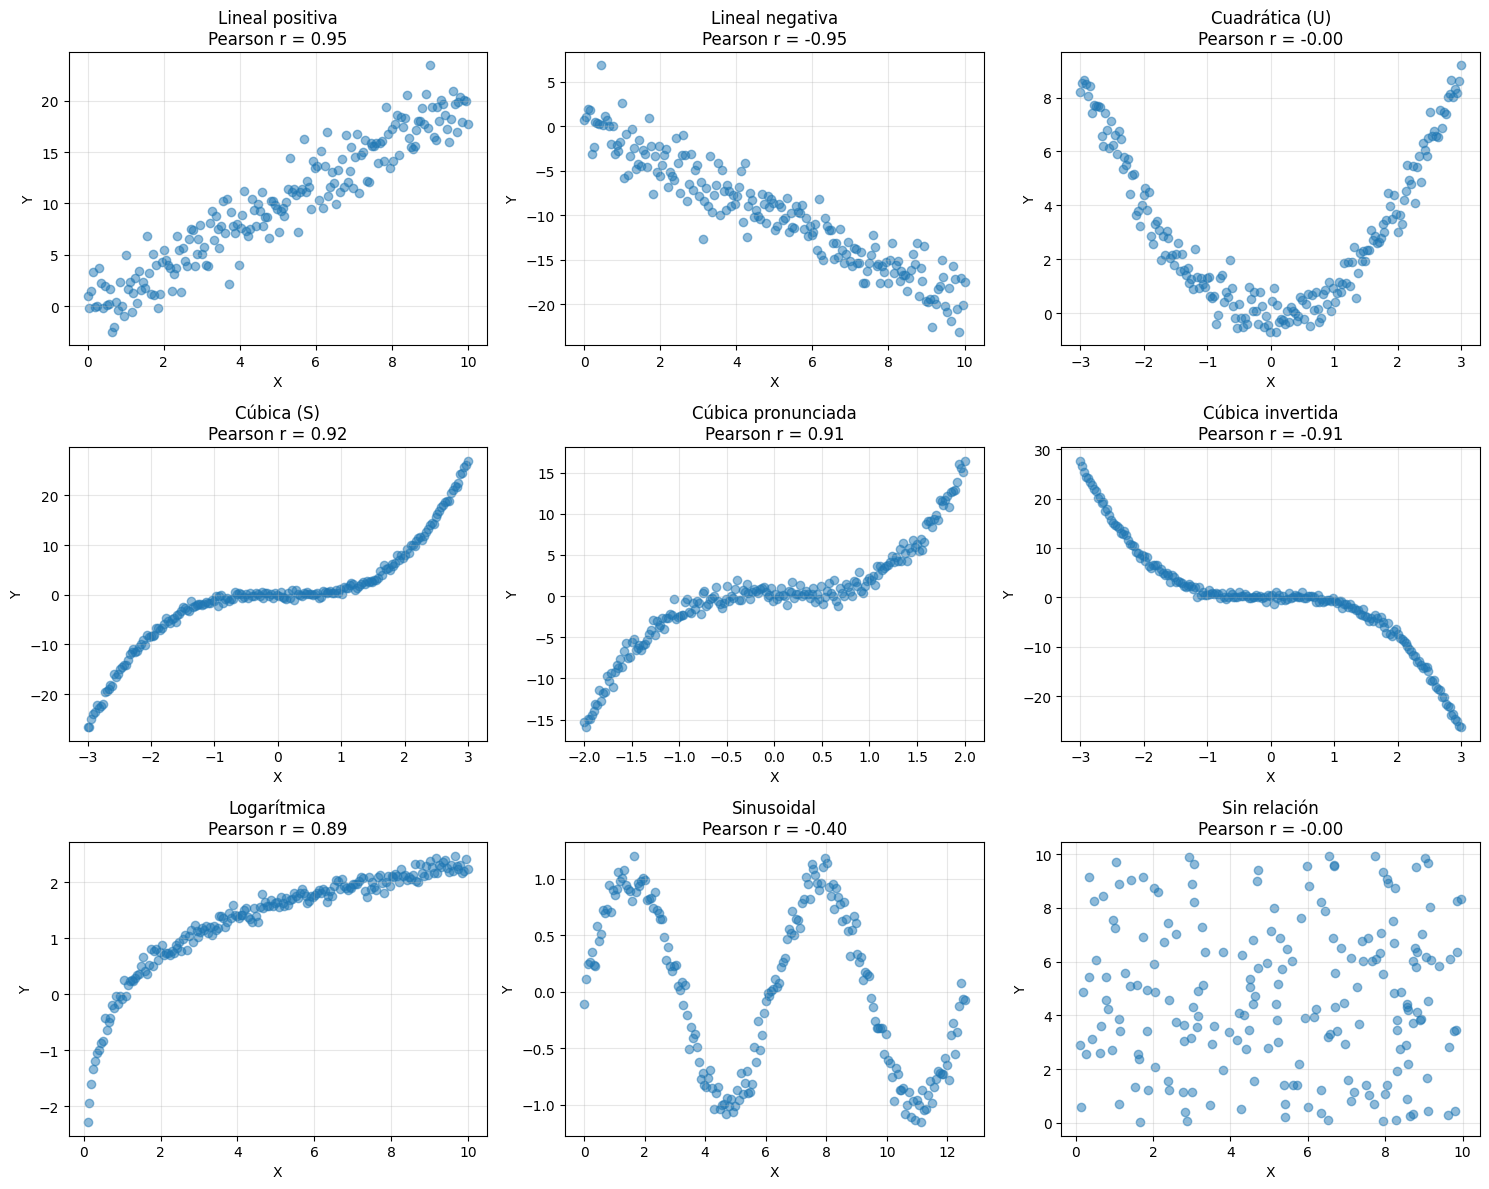

In [99]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import pearsonr, spearmanr

# Crear datos de ejemplo para visualizar
# Estos datos son generados aleatoriamente para ilustrar diferentes tipos de relaciones entre variables numéricas.
np.random.seed(42)
n = 200  # Conjunto de datos con 200 puntos (base)

# 1. Lineal positiva
x_lineal = np.linspace(0, 10, n)
# linspace permite generar un array de n puntos equidistantes entre 0 y 10
y_lineal = 2 * x_lineal + np.random.normal(0, 2, n)

# 2. Lineal negativa
x_lineal_neg = np.linspace(0, 10, n)
# linspace permite generar un array de n puntos equidistantes entre 0 y 10
y_lineal_neg = -2 * x_lineal_neg + np.random.normal(0, 2, n)

# 3. No lineal - cuadrática (parábola)
x_cuad = np.linspace(-3, 3, n)
# linspace permite generar un array de n puntos equidistantes entre -3 y 3
y_cuad = x_cuad**2 + np.random.normal(0, 0.5, n) # algo de ruido para que no sea perfecta

# 4a. Cúbica pura (forma de S)
x_cub1 = np.linspace(-3, 3, n)
y_cub1 = x_cub1**3 + np.random.normal(0, 0.5, n)

# 4b. Cúbica con pendiente (más pronunciada)
x_cub2 = np.linspace(-2, 2, n)
y_cub2 = 2 * x_cub2**3 + np.random.normal(0, 0.8, n)

# 4c. Cúbica invertida
x_cub3 = np.linspace(-3, 3, n)
y_cub3 = -x_cub3**3 + np.random.normal(0, 0.5, n)

# 5. No lineal - logarítmica
x_log = np.linspace(0.1, 10, n)
# linspace permite generar un array de n puntos equidistantes entre 0.1 y 10
y_log = np.log(x_log) + np.random.normal(0, 0.1, n)

# 6. No lineal - sinusoidal
x_sin = np.linspace(0, 4*np.pi, n)
# linspace permite generar un array de n puntos equidistantes entre 0 y 4*pi
y_sin = np.sin(x_sin) + np.random.normal(0, 0.1, n)

# 7. No relación
x_none = np.random.uniform(0, 10, n)
y_none = np.random.uniform(0, 10, n)

# Visualizar - AHORA CON 3 FILAS para incluir las cúbicas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Calcular correlaciones
corr_lineal, _ = pearsonr(x_lineal, y_lineal)
corr_lineal_neg, _ = pearsonr(x_lineal_neg, y_lineal_neg)
corr_cuad, _ = pearsonr(x_cuad, y_cuad)
corr_cub1, _ = pearsonr(x_cub1, y_cub1)
corr_cub2, _ = pearsonr(x_cub2, y_cub2)
corr_cub3, _ = pearsonr(x_cub3, y_cub3)
corr_log, _ = pearsonr(x_log, y_log)
corr_sin, _ = pearsonr(x_sin, y_sin)
corr_none, _ = pearsonr(x_none, y_none)

# Gráficos - Fila 1
axes[0,0].scatter(x_lineal, y_lineal, alpha=0.5)
axes[0,0].set_title(f'Lineal positiva\nPearson r = {corr_lineal:.2f}')
axes[0,0].set_xlabel('X'); axes[0,0].set_ylabel('Y')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].scatter(x_lineal_neg, y_lineal_neg, alpha=0.5)
axes[0,1].set_title(f'Lineal negativa\nPearson r = {corr_lineal_neg:.2f}')
axes[0,1].set_xlabel('X'); axes[0,1].set_ylabel('Y')
axes[0,1].grid(True, alpha=0.3)

axes[0,2].scatter(x_cuad, y_cuad, alpha=0.5)
axes[0,2].set_title(f'Cuadrática (U)\nPearson r = {corr_cuad:.2f}')
axes[0,2].set_xlabel('X'); axes[0,2].set_ylabel('Y')
axes[0,2].grid(True, alpha=0.3)

# Gráficos - Fila 2 (cúbicas)
axes[1,0].scatter(x_cub1, y_cub1, alpha=0.5)
axes[1,0].set_title(f'Cúbica (S)\nPearson r = {corr_cub1:.2f}')
axes[1,0].set_xlabel('X'); axes[1,0].set_ylabel('Y')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].scatter(x_cub2, y_cub2, alpha=0.5)
axes[1,1].set_title(f'Cúbica pronunciada\nPearson r = {corr_cub2:.2f}')
axes[1,1].set_xlabel('X'); axes[1,1].set_ylabel('Y')
axes[1,1].grid(True, alpha=0.3)

axes[1,2].scatter(x_cub3, y_cub3, alpha=0.5)
axes[1,2].set_title(f'Cúbica invertida\nPearson r = {corr_cub3:.2f}')
axes[1,2].set_xlabel('X'); axes[1,2].set_ylabel('Y')
axes[1,2].grid(True, alpha=0.3)

# Gráficos - Fila 3
axes[2,0].scatter(x_log, y_log, alpha=0.5)
axes[2,0].set_title(f'Logarítmica\nPearson r = {corr_log:.2f}')
axes[2,0].set_xlabel('X'); axes[2,0].set_ylabel('Y')
axes[2,0].grid(True, alpha=0.3)

axes[2,1].scatter(x_sin, y_sin, alpha=0.5)
axes[2,1].set_title(f'Sinusoidal\nPearson r = {corr_sin:.2f}')
axes[2,1].set_xlabel('X'); axes[2,1].set_ylabel('Y')
axes[2,1].grid(True, alpha=0.3)

axes[2,2].scatter(x_none, y_none, alpha=0.5)
axes[2,2].set_title(f'Sin relación\nPearson r = {corr_none:.2f}')
axes[2,2].set_xlabel('X'); axes[2,2].set_ylabel('Y')
axes[2,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [93]:
print("Correlación Lineal Positiva:", corr_lineal)
print("Correlación Lineal Negativa:", corr_lineal_neg)
print("\n")
print("coeficientes de correlación entre x_lineal y y_lineal:")
np.corrcoef(x_lineal, y_lineal)
# quiere decir que la correlación entre x_lineal y y_lineal es aproximadamente 0.95, lo que indica una fuerte correlación positiva, como se observa en el gráfico de dispersión.


Correlación Lineal Positiva: 0.9545705138458981
Correlación Lineal Negativa: -0.9472303923645073


coeficientes de correlación entre x_lineal y y_lineal:


array([[1.        , 0.95457051],
       [0.95457051, 1.        ]])

In [95]:
print("Correlación Cuadrática:", corr_cuad) 
np.corrcoef(x_cuad, y_cuad)
# quiere decir que la correlación entre x_cuad y y_cuad es aproximadamente -0.0016, lo que indica que no hay una correlación lineal entre estas variables, a pesar de que visualmente se observa una relación cuadrática (en forma de U) en el gráfico de dispersión. Esto resalta la limitación de la correlación de Pearson para detectar relaciones no lineales.

Correlación Cuadrática: -0.001596226768859562


array([[ 1.        , -0.00159623],
       [-0.00159623,  1.        ]])

📊 EJEMPLO: RELACIÓN PERFECTA NO LINEAL
y = x² (relación perfecta, pero NO lineal)

Coeficiente de Pearson (lineal): r = -0.000
Coeficiente de Spearman (monotónico): ρ = -0.003

⚠️ Pearson da 0 aunque la relación es PERFECTA!
   Porque solo mide relaciones lineales.


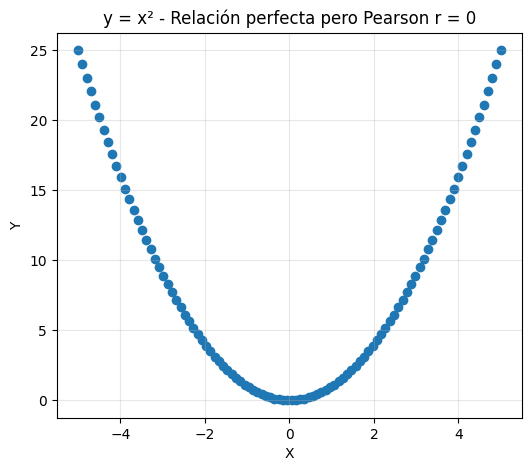

In [ ]:
## 🔍 ¿Por qué el coeficiente de Pearson falla en no lineales?
# 
# # Ejemplo dramático: relación perfecta pero no lineal
x = np.linspace(-5, 5, 100)
y = x**2  # Relación cuadrática PERFECTA

corr_pearson, _ = pearsonr(x, y)
corr_spearman, _ = spearmanr(x, y)

print("="*50)
print("📊 EJEMPLO: RELACIÓN PERFECTA NO LINEAL")
print("="*50)
print(f"y = x² (relación perfecta, pero NO lineal)")
print(f"\nCoeficiente de Pearson (lineal): r = {corr_pearson:.3f}")
print(f"Coeficiente de Spearman (monotónico): ρ = {corr_spearman:.3f}")
print("\n⚠️ Pearson da 0 aunque la relación es PERFECTA!")
print("   Porque solo mide relaciones lineales.")

plt.figure(figsize=(6, 5))
plt.scatter(x, y)
plt.title('y = x² - Relación perfecta pero Pearson r = 0')
plt.xlabel('X'); plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
## 📈 Métodos para detectar correlaciones no lineales

In [ ]:
### 1. **Spearman (correlación de rangos)**
# Mide relaciones **monotónicas** (siempre creciente o siempre decreciente, aunque no sea lineal)

from scipy.stats import spearmanr

# Calcular Spearman
rho, p_valor = spearmanr(df['bill_length_mm'], df['bill_depth_mm'])

print(f"Correlación de Spearman: ρ = {rho:.3f}")
print(f"Correlación de Pearson: r = {corr_general:.3f}")
print("\nSi ρ es muy diferente a r, puede haber no linealidad o outliers")

Correlación de Spearman: ρ = nan
Correlación de Pearson: r = -0.235

Si ρ es muy diferente a r, puede haber no linealidad o outliers


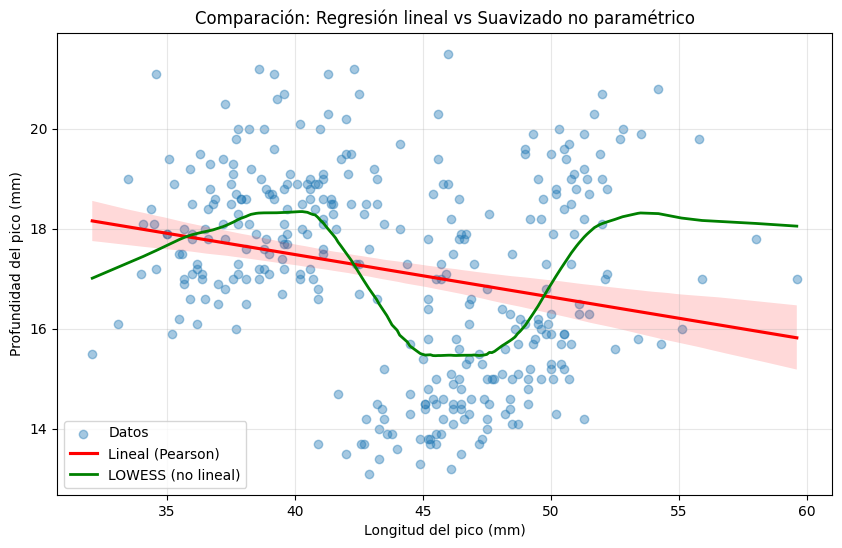

In [ ]:
### 2. **Visualización con LOWESS (suavizado local)**
# from statsmodels.nonparametric.smoothers_lowess import lowess

plt.figure(figsize=(10, 6))

# Scatter original
plt.scatter(df['bill_length_mm'], df['bill_depth_mm'], 
            alpha=0.4, label='Datos')

# Línea de regresión lineal (Pearson)
sns.regplot(data=df, x='bill_length_mm', y='bill_depth_mm',
            scatter=False, color='red', label='Lineal (Pearson)')

# LOWESS - curva suavizada no paramétrica
lowess_smooth = lowess(df['bill_depth_mm'], df['bill_length_mm'], 
                       frac=0.3)  # frac = proporción de datos para suavizado
plt.plot(lowess_smooth[:, 0], lowess_smooth[:, 1], 
         color='green', linewidth=2, label='LOWESS (no lineal)')

plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Profundidad del pico (mm)')
plt.title('Comparación: Regresión lineal vs Suavizado no paramétrico')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

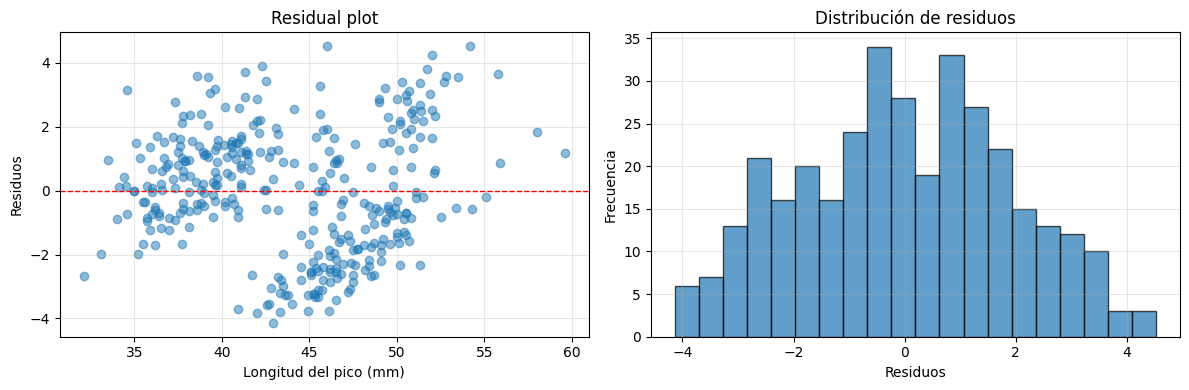


🔍 DIAGNÓSTICO DE LINEALIDAD:
Si los residuos muestran un patrón (U, forma de cono, etc.):
  → Hay relación NO LINEAL
Si los residuos están aleatorios alrededor de 0:
  → La relación es LINEAL


In [81]:
### 3. **Residual plot (para diagnosticar no linealidad)**

from sklearn.linear_model import LinearRegression

# Ajustar regresión lineal
X = df['bill_length_mm'].dropna().values.reshape(-1, 1)
y = df['bill_depth_mm'].dropna().values

modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)
residuos = y - y_pred

# Graficar residuos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Scatter con residuos
ax1.scatter(X, residuos, alpha=0.5)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('Longitud del pico (mm)')
ax1.set_ylabel('Residuos')
ax1.set_title('Residual plot')
ax1.grid(True, alpha=0.3)

# Histograma de residuos
ax2.hist(residuos, bins=20, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Residuos')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de residuos')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación
print("\n🔍 DIAGNÓSTICO DE LINEALIDAD:")
print("="*40)
print("Si los residuos muestran un patrón (U, forma de cono, etc.):")
print("  → Hay relación NO LINEAL")
print("Si los residuos están aleatorios alrededor de 0:")
print("  → La relación es LINEAL")

## 📚 Comparación de coeficientes de correlación

| Coeficiente | Qué mide | Cuándo usarlo |
|-------------|----------|---------------|
| **Pearson (r)** | Relación lineal | Datos normales, relación lineal |
| **Spearman (ρ)** | Relación monótona (siempre crece o decrece) | Datos no normales, relaciones no lineales pero monótonas |
| **Kendall (τ)** | Similar a Spearman, más robusto | Muestras pequeñas, muchos empates |

In [82]:
from scipy.stats import pearsonr, spearmanr, kendalltau

# Comparar los tres
r, _ = pearsonr(df['bill_length_mm'].dropna(), df['bill_depth_mm'].dropna())
rho, _ = spearmanr(df['bill_length_mm'].dropna(), df['bill_depth_mm'].dropna())
tau, _ = kendalltau(df['bill_length_mm'].dropna(), df['bill_depth_mm'].dropna())

print("📊 COMPARACIÓN DE COEFICIENTES")
print("="*40)
print(f"Pearson (lineal):     r  = {r:.3f}")
print(f"Spearman (monótono):  ρ  = {rho:.3f}")
print(f"Kendall (monótono):   τ  = {tau:.3f}")

📊 COMPARACIÓN DE COEFICIENTES
Pearson (lineal):     r  = -0.235
Spearman (monótono):  ρ  = -0.222
Kendall (monótono):   τ  = -0.123


In [ ]:
## 🐧 Aplicación a tus datos de pingüinos

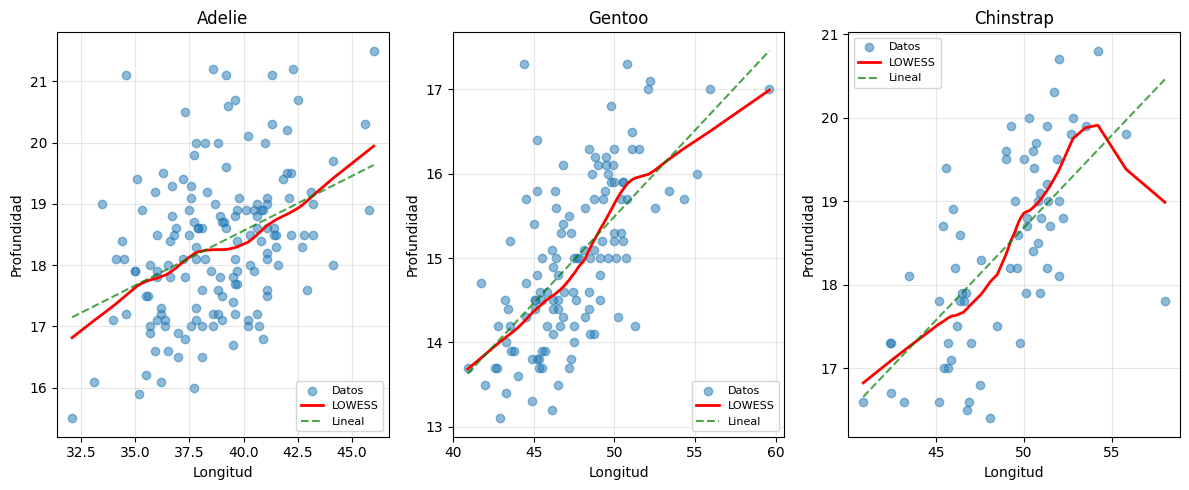


📊 CORRELACIÓN DE SPEARMAN POR ESPECIE:

🐧 Adelie:
   Pearson (lineal):  r = 0.391
   Spearman (monótono): ρ = 0.363
   Diferencia: 0.029

🐧 Gentoo:
   Pearson (lineal):  r = 0.643
   Spearman (monótono): ρ = 0.635
   Diferencia: 0.008

🐧 Chinstrap:
   Pearson (lineal):  r = 0.654
   Spearman (monótono): ρ = 0.672
   Diferencia: 0.018


In [83]:
# Ver si hay no linealidad en tus datos
plt.figure(figsize=(12, 5))

# Por especie, analizar no linealidad
for i, especie in enumerate(df['species'].unique(), 1):
    plt.subplot(1, 3, i)
    df_esp = df[df['species'] == especie].dropna(subset=['bill_length_mm', 'bill_depth_mm'])
    
    # Scatter
    plt.scatter(df_esp['bill_length_mm'], df_esp['bill_depth_mm'], 
                alpha=0.5, label='Datos')
    
    # LOWESS
    lowess_smooth = lowess(df_esp['bill_depth_mm'], df_esp['bill_length_mm'], frac=0.5)
    plt.plot(lowess_smooth[:, 0], lowess_smooth[:, 1], 
             color='red', linewidth=2, label='LOWESS')
    
    # Regresión lineal
    z = np.polyfit(df_esp['bill_length_mm'], df_esp['bill_depth_mm'], 1)
    p = np.poly1d(z)
    plt.plot(df_esp['bill_length_mm'].sort_values(), 
             p(df_esp['bill_length_mm'].sort_values()), 
             'g--', label='Lineal', alpha=0.7)
    
    plt.title(f'{especie}')
    plt.xlabel('Longitud')
    plt.ylabel('Profundidad')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular Spearman por especie
print("\n📊 CORRELACIÓN DE SPEARMAN POR ESPECIE:")
print("="*50)
for especie in df['species'].unique():
    df_esp = df[df['species'] == especie].dropna(subset=['bill_length_mm', 'bill_depth_mm'])
    r_pearson, _ = pearsonr(df_esp['bill_length_mm'], df_esp['bill_depth_mm'])
    rho_spearman, _ = spearmanr(df_esp['bill_length_mm'], df_esp['bill_depth_mm'])
    print(f"\n🐧 {especie}:")
    print(f"   Pearson (lineal):  r = {r_pearson:.3f}")
    print(f"   Spearman (monótono): ρ = {rho_spearman:.3f}")
    print(f"   Diferencia: {abs(r_pearson - rho_spearman):.3f}")
    
    if abs(r_pearson - rho_spearman) > 0.1:
        print(f"   ⚠️ Posible no linealidad o outliers significativos")

Especie	Pearson (r)	Spearman (ρ)	Diferencia	Interpretación  
Adelie	0.391	0.363	0.029	Muy cercanos → lineal  
Gentoo	0.643	0.635	0.008	Casi idénticos → lineal  
Chinstrap	0.654	0.672	0.018	Muy cercanos → lineal  

 
Diferencia < 0.1 → La relación es lineal ✅  
Diferencia > 0.2 → Posible no linealidad ⚠️  
En tu caso, todas las diferencias son menores a 0.03, lo que indica que:  
La relación lineal captura bien el patrón  
No hay curvaturas significativas dentro de cada especie  
Puedes confiar en el coeficiente de Pearson para interpretar la fuerza y dirección de la relación  


